# Alzheimer's MRI Dataset Exploration

This notebook explores the MRI dataset, checks preprocessing, analyzes class imbalance, and optionally inspects the clinical CSV dataset. All figures are saved to `evaluation/plots/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from sklearn.feature_selection import mutual_info_classif
from torchvision import datasets, transforms

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

ROOT_DIR = Path("..").resolve()
MRI_DIR = ROOT_DIR / "data" / "raw" / "MRI"
CLINICAL_CSV = ROOT_DIR / "data" / "raw" / "clinical" / "alzheimers_dataset.csv"
PLOTS_DIR = ROOT_DIR / "evaluation" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MRI_DIR, CLINICAL_CSV, PLOTS_DIR

(WindowsPath('C:/ALZHEIMER_DETECTION/data/raw/MRI'),
 WindowsPath('C:/ALZHEIMER_DETECTION/data/raw/clinical/alzheimers_dataset.csv'),
 WindowsPath('C:/ALZHEIMER_DETECTION/evaluation/plots'))

## 1. Dataset Loading & Overview
Load MRI images using `ImageFolder`, count images per class, and measure class imbalance.

,Class,Images,Percentage
0,Alzhiemer,44000,100.0


Total images: 44000
Class imbalance ratio (max/min): 1.00


C:\Users\HP\AppData\Local\Temp\ipykernel_31148\4241096053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=overview_df, x='Class', y='Images', palette='viridis')


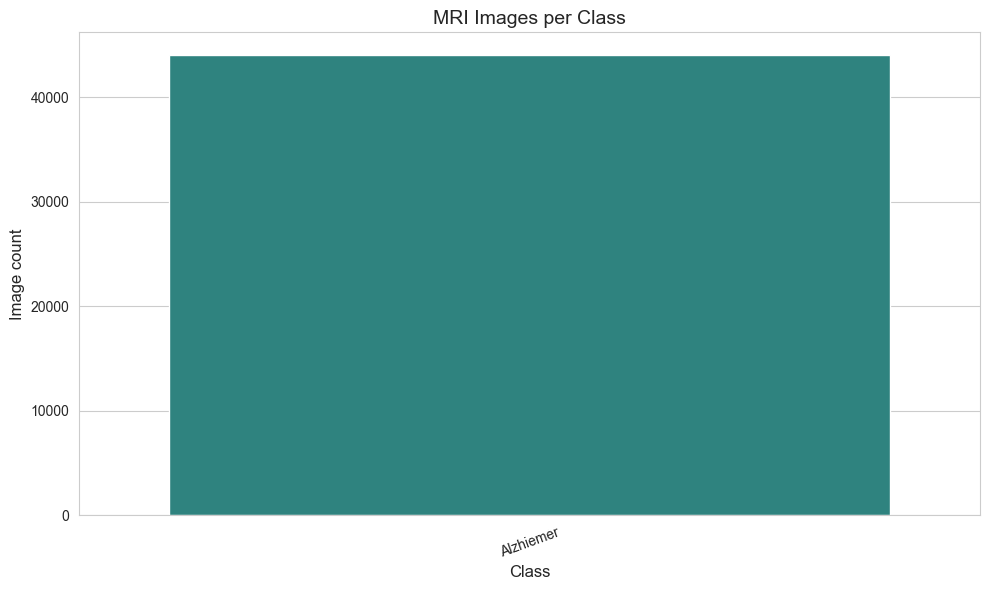

In [2]:
image_dataset = datasets.ImageFolder(MRI_DIR)
class_names = image_dataset.classes
class_to_idx = image_dataset.class_to_idx
counts = pd.Series(image_dataset.targets).value_counts().sort_index()
counts.index = class_names
total_images = int(counts.sum())
imbalance_ratio = float(counts.max() / counts.min()) if counts.min() > 0 else np.nan

overview_df = pd.DataFrame({
    'Class': counts.index,
    'Images': counts.values,
    'Percentage': (counts.values / total_images) * 100
})
display(overview_df)
print(f'Total images: {total_images}')
print(f'Class imbalance ratio (max/min): {imbalance_ratio:.2f}')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=overview_df, x='Class', y='Images', palette='viridis')
ax.set_title('MRI Images per Class')
ax.set_xlabel('Class')
ax.set_ylabel('Image count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'mri_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Sample Visualization
Show a 4x4 grid of MRI samples and a best-effort side-by-side comparison of the same patient across stages when a matching file prefix is available.

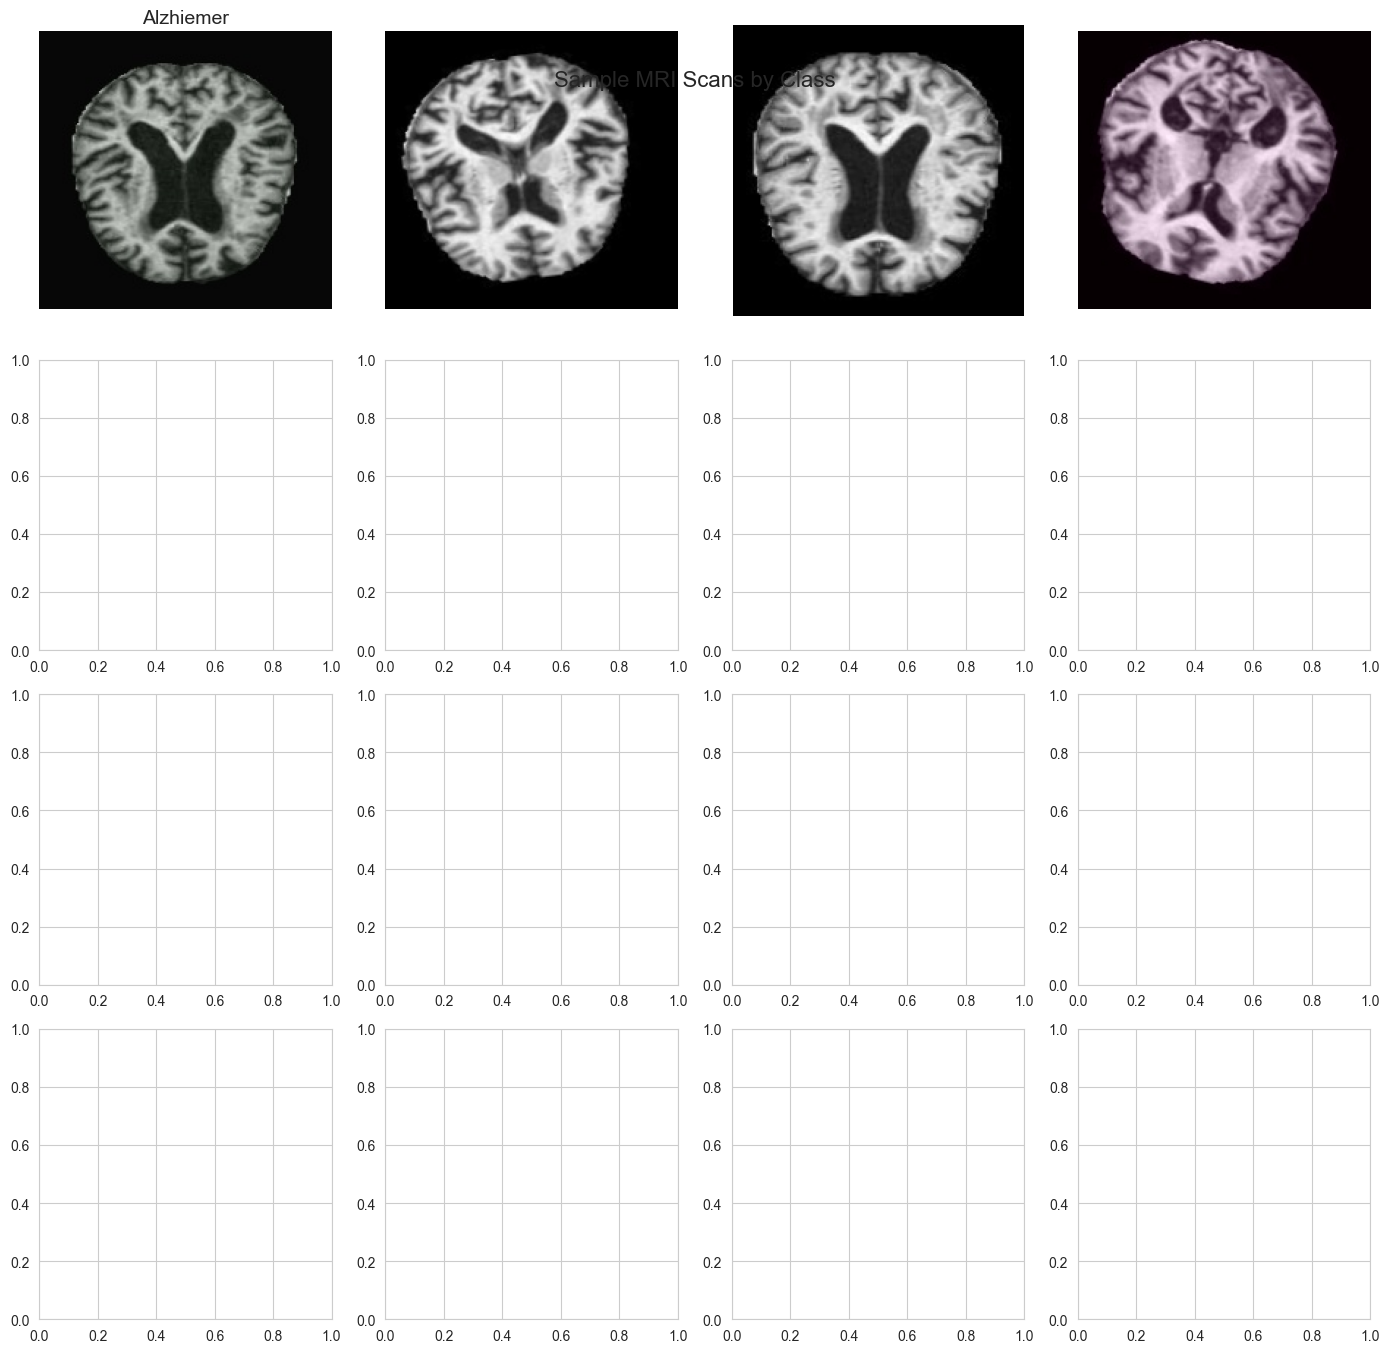

No obvious same-patient multi-stage match found in filenames. Skipping side-by-side comparison.


In [3]:
to_pil = transforms.ToPILImage()
to_tensor = transforms.ToTensor()

def load_image(path):
    return Image.open(path).convert('RGB')

def strip_stage_suffix(stem):
    parts = stem.replace('-', '_').split('_')
    if len(parts) <= 1:
        return stem
    stage_tokens = {'non', 'nondemented', 'verymild', 'mild', 'moderate', 'demented'}
    prefix = []
    for part in parts:
        normalized = part.lower()
        if normalized in stage_tokens:
            break
        prefix.append(part)
    return '_'.join(prefix) if prefix else stem

def show_class_samples(dataset, class_names, samples_per_class=4):
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    for row_idx, class_name in enumerate(class_names):
        class_indices = [i for i, target in enumerate(dataset.targets) if target == row_idx]
        chosen = class_indices[:samples_per_class]
        for col_idx in range(4):
            ax = axes[row_idx, col_idx]
            if col_idx < len(chosen):
                image_path, _ = dataset.samples[chosen[col_idx]]
                image = load_image(image_path)
                ax.imshow(image, cmap='gray')
                ax.set_title(class_name if col_idx == 0 else '')
            ax.axis('off')
    plt.suptitle('Sample MRI Scans by Class', y=0.92, fontsize=16)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'sample_mri_grid.png', dpi=300, bbox_inches='tight')
    plt.show()

show_class_samples(image_dataset, class_names)

def show_same_patient_across_stages(dataset, class_names):
    grouped = {}
    for image_path, _ in dataset.samples:
        stem = Path(image_path).stem
        key = strip_stage_suffix(stem)
        grouped.setdefault(key, []).append(image_path)

    candidate = None
    for key, paths in grouped.items():
        stage_hits = [path for path in paths if any(stage.lower().replace(' ', '') in Path(path).stem.lower().replace('_', '') for stage in class_names)]
        if len(stage_hits) >= 2:
            candidate = sorted(stage_hits)[:4]
            break

    if candidate is None:
        print('No obvious same-patient multi-stage match found in filenames. Skipping side-by-side comparison.')
        return

    fig, axes = plt.subplots(1, len(candidate), figsize=(4 * len(candidate), 4))
    if len(candidate) == 1:
        axes = [axes]
    for ax, path in zip(axes, candidate):
        ax.imshow(load_image(path), cmap='gray')
        ax.set_title(Path(path).stem[:30])
        ax.axis('off')
    plt.suptitle('Same Patient Across Stages (Filename-Based Match)', y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'same_patient_across_stages.png', dpi=300, bbox_inches='tight')
    plt.show()

show_same_patient_across_stages(image_dataset, class_names)

## 3. Image Statistics
Compute per-class mean and standard deviation, image size distribution, and brightness/contrast distributions.

In [ ]:
import gc

def compute_image_stats(image_path):
    """Compute statistics for a single image."""
    try:
        image = np.array(Image.open(image_path).convert('L'), dtype=np.float32) / 255.0
        return {
            'mean': float(image.mean()),
            'std': float(image.std()),
            'min': float(image.min()),
            'max': float(image.max()),
            'height': image.shape[0],
            'width': image.shape[1]
        }
    except:
        return None

# Compute stats per class (with sampling to avoid memory overload)
stats_per_class = {}
all_means = []
all_stds = []
max_samples_per_class = 500  # Limit to prevent memory issues

for class_idx, class_name in enumerate(class_names):
    class_indices = [i for i, target in enumerate(image_dataset.targets) if target == class_idx]
    # Sample if too many
    sampled_indices = class_indices[:max_samples_per_class] if len(class_indices) > max_samples_per_class else class_indices
    class_stats = []
    
    for idx in sampled_indices:
        image_path, _ = image_dataset.samples[idx]
        stats = compute_image_stats(image_path)
        if stats:
            class_stats.append(stats)
            all_means.append(stats['mean'])
            all_stds.append(stats['std'])
    
    stats_df = pd.DataFrame(class_stats)
    if len(stats_df) > 0:
        stats_per_class[class_name] = {
            'mean_brightness': stats_df['mean'].mean(),
            'std_brightness': stats_df['mean'].std(),
            'mean_contrast': stats_df['std'].mean(),
            'std_contrast': stats_df['std'].std(),
            'avg_height': int(stats_df['height'].mean()),
            'avg_width': int(stats_df['width'].mean()),
            'n_samples': len(stats_df)
        }
    gc.collect()  # Free memory between classes

# Display stats
stats_summary = pd.DataFrame(stats_per_class).T
print("\nImage Statistics by Class:")
print(stats_summary.round(3).to_string())
print(f"\nOverall mean brightness: {np.mean(all_means):.3f}")
print(f"Overall mean contrast (std): {np.mean(all_stds):.3f}")
print(f"\nNote: Statistics computed on up to {max_samples_per_class} samples per class")
gc.collect()


Image Statistics by Class:
           mean_brightness  std_brightness  mean_contrast  std_contrast  avg_height  avg_width
Alzhiemer            0.293           0.066           0.31         0.045       191.0      193.0

Overall mean brightness: 0.293
Overall mean contrast (std): 0.310


C:\Users\HP\AppData\Local\Temp\ipykernel_31148\2751318013.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(brightness_by_class, labels=class_names, patch_artist=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_31148\2751318013.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(contrast_by_class, labels=class_names, patch_artist=True)


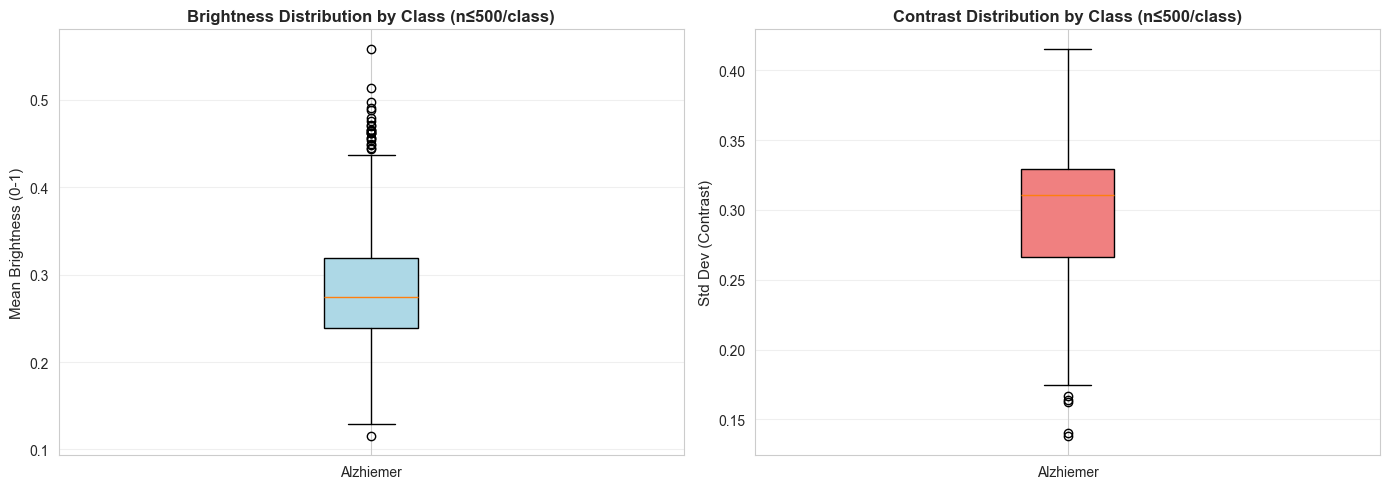

Saved: C:\ALZHEIMER_DETECTION\evaluation\plots\image_brightness_contrast.png


18

In [13]:
# Plot brightness and contrast distributions (using sampling to avoid memory issues)
import gc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_samples_per_class = 500  # Limit samples to avoid memory overload

# Brightness distribution
ax = axes[0]
brightness_by_class = []
for class_idx, class_name in enumerate(class_names):
    class_indices = [i for i, target in enumerate(image_dataset.targets) if target == class_idx]
    # Sample indices if too many
    sampled_indices = class_indices[:max_samples_per_class] if len(class_indices) > max_samples_per_class else class_indices
    means = []
    for idx in sampled_indices:
        image_path, _ = image_dataset.samples[idx]
        try:
            img_array = np.array(Image.open(image_path).convert('L'), dtype=np.float32) / 255.0
            means.append(img_array.mean())
        except Exception as e:
            continue  # Skip corrupted images
    brightness_by_class.append(means)
    gc.collect()  # Free memory

bp = ax.boxplot(brightness_by_class, labels=class_names, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.set_ylabel('Mean Brightness (0-1)', fontsize=11)
ax.set_title(f'Brightness Distribution by Class (n≤{max_samples_per_class}/class)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Contrast distribution
ax = axes[1]
contrast_by_class = []
for class_idx, class_name in enumerate(class_names):
    class_indices = [i for i, target in enumerate(image_dataset.targets) if target == class_idx]
    # Sample indices if too many
    sampled_indices = class_indices[:max_samples_per_class] if len(class_indices) > max_samples_per_class else class_indices
    stds = []
    for idx in sampled_indices:
        image_path, _ = image_dataset.samples[idx]
        try:
            img_array = np.array(Image.open(image_path).convert('L'), dtype=np.float32) / 255.0
            stds.append(img_array.std())
        except Exception as e:
            continue  # Skip corrupted images
    contrast_by_class.append(stds)
    gc.collect()  # Free memory

bp = ax.boxplot(contrast_by_class, labels=class_names, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
ax.set_ylabel('Std Dev (Contrast)', fontsize=11)
ax.set_title(f'Contrast Distribution by Class (n≤{max_samples_per_class}/class)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'image_brightness_contrast.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'image_brightness_contrast.png'}")
gc.collect()

## 4. Preprocessing Verification

Show before/after preprocessing with augmentation transforms applied during training.

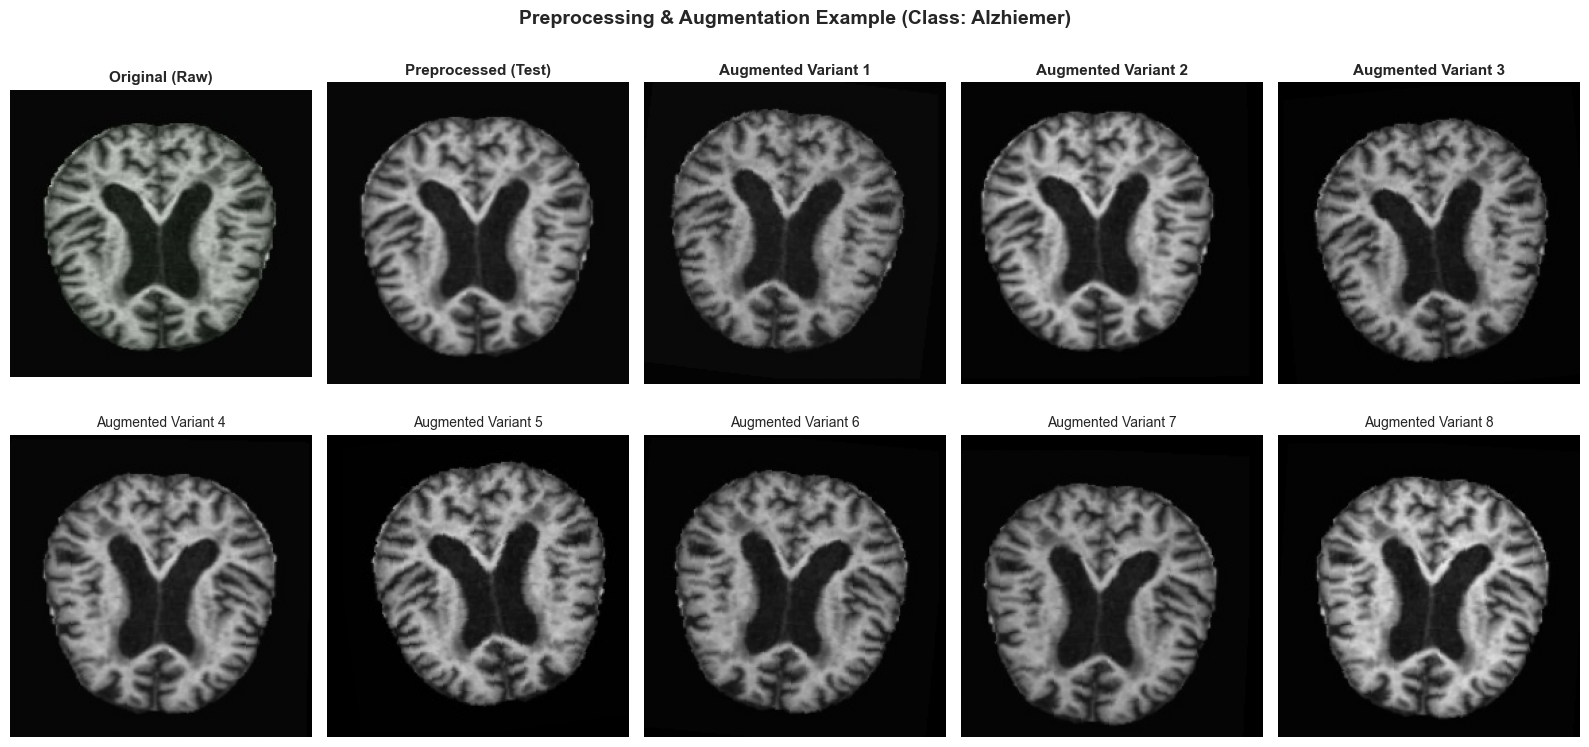

Saved: C:\ALZHEIMER_DETECTION\evaluation\plots\preprocessing_augmentation_demo.png


In [7]:
# Define training transforms (matching train_cnn.py)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Define test transforms (no augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Select first image from dataset
sample_path, sample_class = image_dataset.samples[0]
original_pil = Image.open(sample_path).convert('L')
sample_class_name = class_names[sample_class]

# Apply transforms multiple times for augmentation variety
fig, axes = plt.subplots(2, 5, figsize=(16, 8))

# Row 1: Original and test (no augmentation)
original_rgb = Image.open(sample_path).convert('RGB')
axes[0, 0].imshow(original_rgb, cmap='gray')
axes[0, 0].set_title('Original (Raw)', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

test_processed = test_transforms(original_pil)  # [1, 224, 224]
test_display = test_processed[0].numpy()  # Denormalize for display
axes[0, 1].imshow(test_display, cmap='gray', vmin=-1, vmax=1)
axes[0, 1].set_title('Preprocessed (Test)', fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

# Row 1, cols 2-4: Training augmentations
for i in range(3):
    augmented = train_transforms(original_pil)  # [1, 224, 224]
    augmented_display = augmented[0].numpy()
    axes[0, i + 2].imshow(augmented_display, cmap='gray', vmin=-1, vmax=1)
    axes[0, i + 2].set_title(f'Augmented Variant {i+1}', fontsize=11, fontweight='bold')
    axes[0, i + 2].axis('off')

# Row 2: More augmentation variants
for i in range(5):
    augmented = train_transforms(original_pil)
    augmented_display = augmented[0].numpy()
    axes[1, i].imshow(augmented_display, cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title(f'Augmented Variant {i+4}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle(f'Preprocessing & Augmentation Example (Class: {sample_class_name})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'preprocessing_augmentation_demo.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'preprocessing_augmentation_demo.png'}")

## 5. Class Imbalance Analysis

Compute recommended class weights for balanced training and visualize imbalance severity.

Recommended Class Weights (for CrossEntropyLoss):
  Alzhiemer           : 1.0000


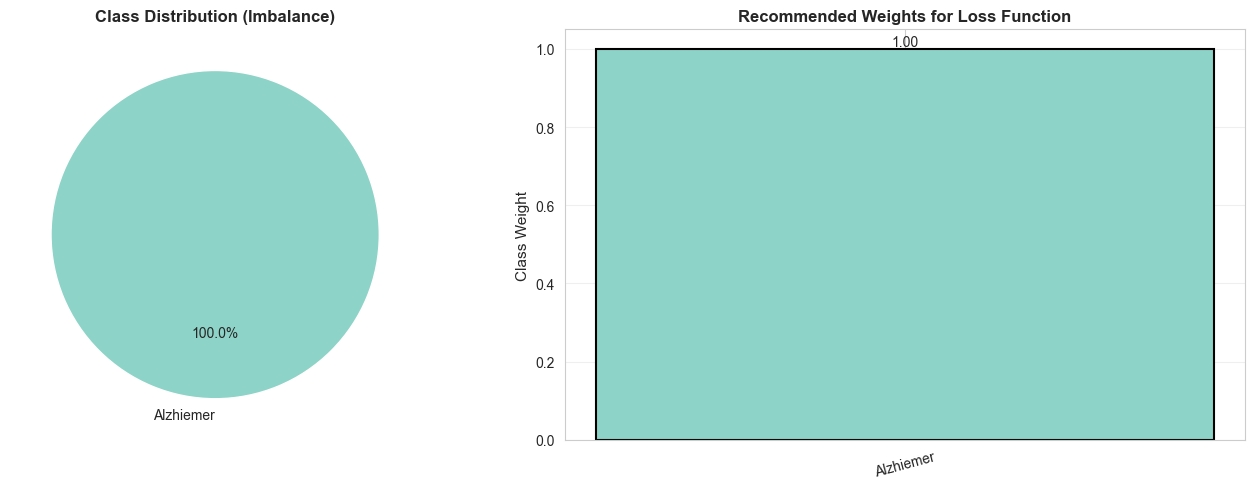

Saved: C:\ALZHEIMER_DETECTION\evaluation\plots\class_imbalance_analysis.png


In [8]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for loss function
targets_array = np.array(image_dataset.targets)
class_weights = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=targets_array)
class_weights_normalized = class_weights / class_weights.sum() * len(class_names)  # Normalize

print("Recommended Class Weights (for CrossEntropyLoss):")
for class_name, weight in zip(class_names, class_weights_normalized):
    print(f"  {class_name:20s}: {weight:.4f}")

# Create class weight dataframe
weight_df = pd.DataFrame({
    'Class': class_names,
    'Count': [counts[cn] for cn in class_names],
    'Weight': class_weights_normalized,
    'Percentage': [100 * counts[cn] / total_images for cn in class_names]
})

# Visualize imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of class distribution
ax = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
ax.pie(weight_df['Count'], labels=weight_df['Class'], autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Class Distribution (Imbalance)', fontsize=12, fontweight='bold')

# Class weights bar chart
ax = axes[1]
bars = ax.bar(weight_df['Class'], weight_df['Weight'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Class Weight', fontsize=11)
ax.set_title('Recommended Weights for Loss Function', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, weight in zip(bars, weight_df['Weight']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{weight:.2f}', ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'class_imbalance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'class_imbalance_analysis.png'}")

## 6. Clinical Data Analysis (Optional)

Load clinical CSV data, analyze feature distributions, and compute feature importance.

In [9]:
# Check if clinical CSV exists
if CLINICAL_CSV.exists():
    print(f"Loading clinical data from: {CLINICAL_CSV}")
    clinical_df = pd.read_csv(CLINICAL_CSV)
    print(f"\nDataset shape: {clinical_df.shape}")
    print(f"\nFirst few rows:")
    print(clinical_df.head())
    print(f"\nColumn names: {list(clinical_df.columns)}")
    print(f"\nData types:")
    print(clinical_df.dtypes)
else:
    print(f"Clinical CSV not found at: {CLINICAL_CSV}")
    print("Skipping clinical data analysis.")
    clinical_df = None

Clinical CSV not found at: C:\ALZHEIMER_DETECTION\data\raw\clinical\alzheimers_dataset.csv
Skipping clinical data analysis.


In [10]:
if clinical_df is not None:
    # Select numeric features and diagnosis column
    numeric_cols = clinical_df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Identify diagnosis/label column (usually named 'diagnosis' or 'group' or 'class')
    diagnosis_cols = [c for c in clinical_df.columns if 'diagnosis' in c.lower() or 'group' in c.lower() or 'class' in c.lower() or 'label' in c.lower()]
    diagnosis_col = diagnosis_cols[0] if diagnosis_cols else None
    
    if diagnosis_col:
        print(f"Using diagnosis column: {diagnosis_col}")
        
        # Compute correlations between numeric features and diagnosis
        numeric_cols_filtered = [col for col in numeric_cols if col != diagnosis_col]
        
        # Create correlation matrix
        if len(numeric_cols_filtered) > 0:
            corr_data = clinical_df[numeric_cols_filtered + [diagnosis_col]].dropna()
            correlation_matrix = corr_data.corr()
            
            # Plot correlation heatmap
            plt.figure(figsize=(12, 10))
            sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                        square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
            plt.title('Clinical Features Correlation Matrix', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / 'clinical_correlation_heatmap.png', dpi=300, bbox_inches='tight')
            plt.show()
            print(f"Saved: {PLOTS_DIR / 'clinical_correlation_heatmap.png'}")
        else:
            print("Not enough numeric features for correlation analysis.")
    else:
        print("No diagnosis/label column detected in clinical data.")

In [11]:
if clinical_df is not None and diagnosis_col:
    # Select key clinical features for detailed analysis
    # Common features: MMSE_score, age, CDR_score, etc.
    key_features = [c for c in numeric_cols if c != diagnosis_col]
    key_features = key_features[:min(5, len(key_features))]  # Use first 5 numeric features
    
    if len(key_features) > 0:
        # Violin plots: distribution by diagnosis group
        n_features = len(key_features)
        fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 5))
        if n_features == 1:
            axes = [axes]
        
        for ax, feature in zip(axes, key_features):
            sns.violinplot(data=clinical_df, x=diagnosis_col, y=feature, ax=ax, palette='Set2')
            ax.set_title(f'{feature} by Diagnosis', fontsize=11, fontweight='bold')
            ax.set_ylabel(feature, fontsize=10)
            ax.set_xlabel(diagnosis_col, fontsize=10)
        
        plt.suptitle('Clinical Feature Distributions by Diagnosis Group', fontsize=14, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'clinical_features_by_diagnosis.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {PLOTS_DIR / 'clinical_features_by_diagnosis.png'}")

In [12]:
if clinical_df is not None and diagnosis_col:
    # Feature importance using mutual information
    numeric_cols_filtered = [col for col in numeric_cols if col != diagnosis_col]
    
    if len(numeric_cols_filtered) > 0:
        # Prepare data
        X = clinical_df[numeric_cols_filtered].fillna(clinical_df[numeric_cols_filtered].mean())
        
        # Encode diagnosis if string
        if clinical_df[diagnosis_col].dtype == 'object':
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()
            y = le.fit_transform(clinical_df[diagnosis_col])
            diagnosis_map = dict(zip(le.classes_, le.transform(le.classes_)))
        else:
            y = clinical_df[diagnosis_col].values
        
        # Compute mutual information
        mi_scores = mutual_info_classif(X, y, random_state=42)
        mi_df = pd.DataFrame({
            'Feature': numeric_cols_filtered,
            'Importance': mi_scores
        }).sort_values('Importance', ascending=False)
        
        print("\nClinical Feature Importance (Mutual Information):")
        print(mi_df.to_string(index=False))
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, 6))
        colors = plt.cm.viridis(np.linspace(0, 1, len(mi_df)))
        bars = ax.barh(mi_df['Feature'], mi_df['Importance'], color=colors, edgecolor='black', linewidth=1)
        ax.set_xlabel('Mutual Information Score', fontsize=11)
        ax.set_title('Clinical Feature Importance for Diagnosis Prediction', fontsize=12, fontweight='bold')
        ax.invert_yaxis()
        
        for bar, score in zip(bars, mi_df['Importance']):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2., f'{score:.3f}', 
                   ha='left', va='center', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'clinical_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {PLOTS_DIR / 'clinical_feature_importance.png'}")

## Summary

This notebook provided a comprehensive exploration of the Alzheimer's MRI dataset:

1. **Dataset Overview**: Loaded and counted images per class, identified class imbalance
2. **Sample Visualization**: Displayed representative samples from each diagnostic class
3. **Image Statistics**: Analyzed brightness and contrast characteristics by class
4. **Preprocessing Verification**: Demonstrated augmentation transforms applied during training
5. **Class Imbalance Analysis**: Computed recommended class weights for balanced loss functions
6. **Clinical Data Analysis**: (Optional) Analyzed correlations, feature distributions, and importance

All figures have been saved to `evaluation/plots/` for use in reports and presentations.